# XGBoost: tres escenarios temporales para `mag_14`

Este notebook adapta el análisis y modelado para trabajar con **tres escenarios**:

| Escenario | Información usada | Meteorología | Objetivo |
|---|---|---|---|
| **Ayer → mañana** | `T-1` | `T-1` | `mag_14` en `T+1` |
| **Ayer → pasado mañana** | `T-1` | `T-1` | `mag_14` en `T+2` |
| **Hoy → mañana** | `T` | `T` | `mag_14` en `T+1` |

El calendario se corresponde siempre con la **fecha objetivo**.

La separación temporal se mantiene:
- train: antes de 2023
- validation: 2023
- test: desde 2024


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()

while not (ROOT / "src" / "database" / "TFM.duckdb").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("No se ha encontrado la raíz del proyecto.")
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "modeling"

DATASETS = {
    "ayer_manana": DATA_DIR / "dataset_mag14_ayer_a_manana.parquet",
    "ayer_pasado_manana": DATA_DIR / "dataset_mag14_ayer_a_pasado_manana.parquet",
    "hoy_manana": DATA_DIR / "dataset_mag14_hoy_a_manana.parquet",
}

print("Directorio:", DATA_DIR)
for name, path in DATASETS.items():
    print(f"{name}: {path}")


Directorio: c:\Users\dasab\Desktop\MASTER\TFM\data\modeling
ayer_manana: c:\Users\dasab\Desktop\MASTER\TFM\data\modeling\dataset_mag14_ayer_a_manana.parquet
ayer_pasado_manana: c:\Users\dasab\Desktop\MASTER\TFM\data\modeling\dataset_mag14_ayer_a_pasado_manana.parquet
hoy_manana: c:\Users\dasab\Desktop\MASTER\TFM\data\modeling\dataset_mag14_hoy_a_manana.parquet


## 1. Carga y comprobación de los tres escenarios

In [2]:
datasets = {}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(
            f"No existe {path}. Ejecuta primero el notebook "
            "'dataset_ml_mag14_horizontes_3_casos.ipynb'."
        )

    d = pd.read_parquet(path)
    d["fecha_referencia"] = pd.to_datetime(d["fecha_referencia"])
    d["fecha_target"] = pd.to_datetime(d["fecha_target"])

    datasets[name] = d

    print(
        f"{name}: {d.shape} | "
        f"{d['fecha_referencia'].min().date()} → "
        f"{d['fecha_referencia'].max().date()}"
    )


ayer_manana: (23647, 39) | 2020-01-07 → 2024-12-29
ayer_pasado_manana: (23634, 39) | 2020-01-07 → 2024-12-28
hoy_manana: (23647, 39) | 2020-01-08 → 2024-12-30


In [3]:
# Validación de las relaciones temporales.
# fecha_referencia representa el día real de la información usada.
expected_days = {
    "ayer_manana": 2,          # T-1 -> T+1
    "ayer_pasado_manana": 3,   # T-1 -> T+2
    "hoy_manana": 1,           # T   -> T+1
}

for name, d in datasets.items():
    delta = (d["fecha_target"] - d["fecha_referencia"]).dt.days
    assert delta.eq(expected_days[name]).all(), (
        f"Relación temporal incorrecta en {name}: "
        f"se esperaba {expected_days[name]} día(s)."
    )

print("✓ Las tres relaciones temporales son correctas.")


✓ Las tres relaciones temporales son correctas.


## 2. Variables del modelo

In [4]:
TARGET = "target"

EXCLUDE = {
    "fecha_referencia",
    "fecha_target",
    "estacion",
    "caso",
    TARGET,
}

def get_feature_columns(d):
    features = [c for c in d.columns if c not in EXCLUDE]

    invalid = [
        c for c in features
        if not (
            pd.api.types.is_numeric_dtype(d[c])
            or pd.api.types.is_bool_dtype(d[c])
            or isinstance(d[c].dtype, pd.CategoricalDtype)
        )
    ]

    if invalid:
        raise TypeError(
            "Hay variables no numéricas que XGBoost no puede usar: "
            + ", ".join(invalid)
        )

    return features

for name, d in datasets.items():
    features = get_feature_columns(d)
    print(f"{name}: {len(features)} variables predictoras")
    print(features)


ayer_manana: 34 variables predictoras
['tipo_estacion', 'latitud', 'longitud', 'altitud', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_7', 'pm25_mean_3', 'pm25_mean_7', 'no2_lag_1', 'no2_lag_2', 'no2_lag_7', 'no2_mean_3', 'no2_mean_7', 'o3_lag_1', 'o3_lag_2', 'o3_lag_7', 'o3_mean_3', 'o3_mean_7', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_7', 'pm10_mean_3', 'pm10_mean_7', 'temperatura', 'humedad', 'precipitacion', 'presion', 'viento_velocidad', 'viento_dir_sin', 'viento_dir_cos', 'laborable_target', 'mes_sin', 'mes_cos']
ayer_pasado_manana: 34 variables predictoras
['tipo_estacion', 'latitud', 'longitud', 'altitud', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_7', 'pm25_mean_3', 'pm25_mean_7', 'no2_lag_1', 'no2_lag_2', 'no2_lag_7', 'no2_mean_3', 'no2_mean_7', 'o3_lag_1', 'o3_lag_2', 'o3_lag_7', 'o3_mean_3', 'o3_mean_7', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_7', 'pm10_mean_3', 'pm10_mean_7', 'temperatura', 'humedad', 'precipitacion', 'presion', 'viento_velocidad', 'viento_dir_sin', 'viento_dir_cos', 'labo

## 3. Separación temporal

In [5]:
splits = {}

for name, d in datasets.items():
    d = d.sort_values(
        ["fecha_referencia", "estacion"]
    ).reset_index(drop=True)

    train = d[d["fecha_referencia"] < "2023-01-01"].copy()

    val = d[
        (d["fecha_referencia"] >= "2023-01-01") &
        (d["fecha_referencia"] < "2024-01-01")
    ].copy()

    test = d[d["fecha_referencia"] >= "2024-01-01"].copy()

    splits[name] = {
        "all": d,
        "train": train,
        "val": val,
        "test": test,
    }

    print(
        f"\n{name}"
        f"\n  Train: {len(train):,}"
        f"\n  Val:   {len(val):,}"
        f"\n  Test:  {len(test):,}"
    )



ayer_manana
  Train: 14,170
  Val:   4,745
  Test:  4,732

ayer_pasado_manana
  Train: 14,170
  Val:   4,745
  Test:  4,719

hoy_manana
  Train: 14,157
  Val:   4,745
  Test:  4,745


## 4. EDA comparativo


AYER_MANANA


count    23647.000000
mean        53.757035
std         23.668690
min          1.208333
25%         35.928542
50%         56.068750
75%         71.916667
max        124.833333
Name: target, dtype: float64

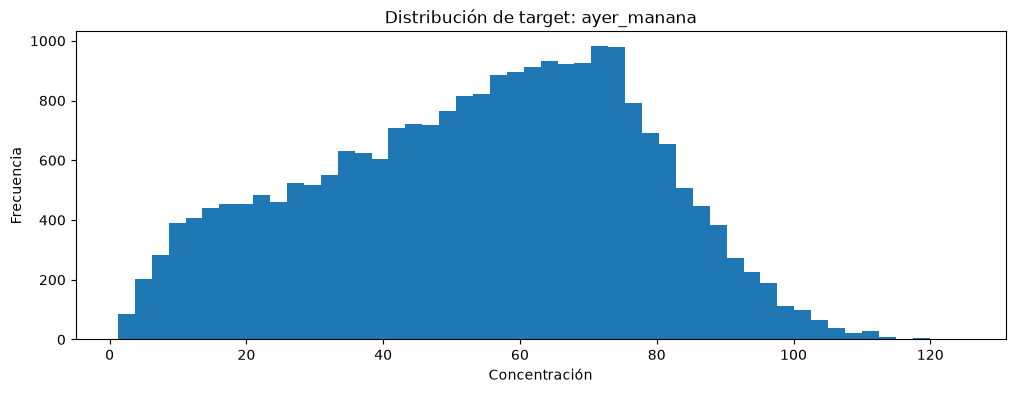


AYER_PASADO_MANANA


count    23634.000000
mean        53.781412
std         23.652304
min          1.208333
25%         35.988478
50%         56.083333
75%         71.933229
max        124.833333
Name: target, dtype: float64

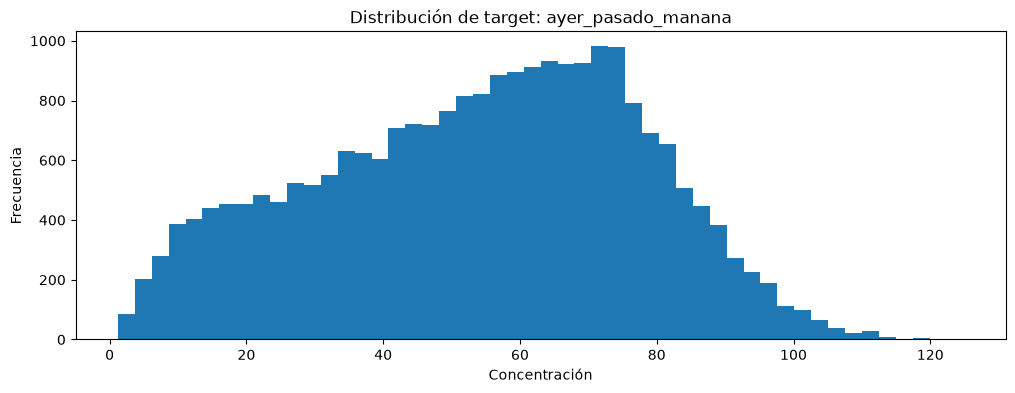


HOY_MANANA


count    23647.000000
mean        53.757035
std         23.668690
min          1.208333
25%         35.928542
50%         56.068750
75%         71.916667
max        124.833333
Name: target, dtype: float64

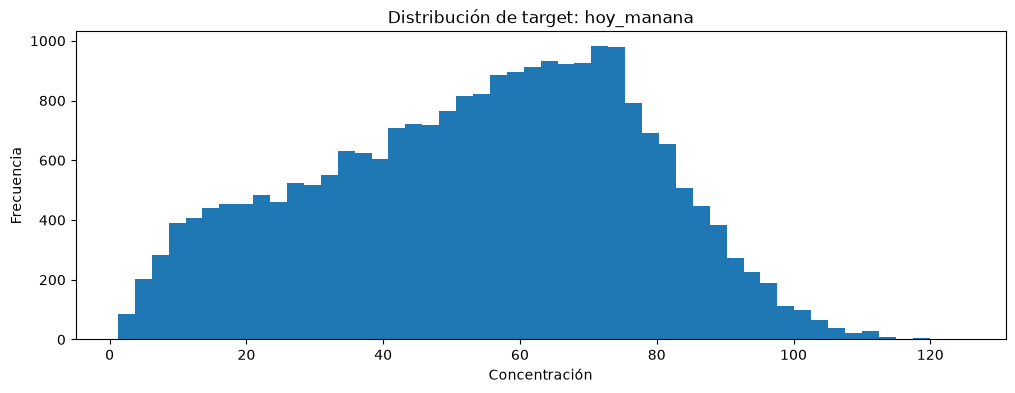

In [6]:
for name, parts in splits.items():
    d = parts["all"]

    print(f"\n{'=' * 60}\n{name.upper()}\n{'=' * 60}")
    display(d[TARGET].describe())

    plt.figure(figsize=(12, 4))
    plt.hist(d[TARGET].dropna(), bins=50)
    plt.title(f"Distribución de {TARGET}: {name}")
    plt.xlabel("Concentración")
    plt.ylabel("Frecuencia")
    plt.show()


## 5. Persistencia, como referencia

In [7]:
# La persistencia solo tiene sentido como baseline cuando la referencia
# corresponde al día inmediatamente anterior conocido.
# Para mantener la comparación homogénea, usamos el último valor disponible
# del contaminante objetivo dentro de las variables históricas.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, parts in splits.items():
    train = parts["train"]
    val = parts["val"]

    # El lag_1 representa el valor del contaminante del día anterior
    # respecto de la fecha de referencia.
    persistence_col = "pm25_lag_1"

    if persistence_col not in val.columns:
        print(f"{name}: no existe {persistence_col}; se omite baseline.")
        continue

    mask = val[TARGET].notna() & val[persistence_col].notna()

    if mask.sum() == 0:
        continue

    y = val.loc[mask, TARGET]
    pred = val.loc[mask, persistence_col]

    results.append({
        "escenario": name,
        "modelo": "Persistencia lag_1",
        "split": "validation",
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
    })

pd.DataFrame(results)


,escenario,modelo,split,MAE,RMSE,R2
0,ayer_manana,Persistencia lag_1,validation,12.735714,16.396891,0.515606
1,ayer_pasado_manana,Persistencia lag_1,validation,13.726805,17.549734,0.444192
2,hoy_manana,Persistencia lag_1,validation,12.672005,16.313115,0.517125


In [8]:
# Normalización defensiva de tipos antes de entrenar XGBoost.
mapa_tipo_estacion = {
    "tráfico": 1,
    "trafico": 1,
    "fondo": 0,
}

for name, d in datasets.items():
    d = d.copy()

    if "tipo_estacion" in d.columns:
        if not pd.api.types.is_numeric_dtype(d["tipo_estacion"]):
            d["tipo_estacion"] = (
                d["tipo_estacion"]
                .astype("string")
                .str.strip()
                .str.lower()
                .map(mapa_tipo_estacion)
            )

        # XGBoost acepta int/float/bool. Usamos float para evitar problemas
        # con valores nulos o dtypes extension.
        d["tipo_estacion"] = d["tipo_estacion"].astype(float)

    datasets[name] = d

for name, d in datasets.items():
    print(
        f"{name}: tipo_estacion="
        f"{d['tipo_estacion'].dtype if 'tipo_estacion' in d.columns else 'no existe'}"
    )


ayer_manana: tipo_estacion=float64
ayer_pasado_manana: tipo_estacion=float64
hoy_manana: tipo_estacion=float64


## 6. XGBoost base en los tres escenarios

In [9]:
from xgboost import XGBRegressor

def split_xy(parts):
    train = parts["train"]
    val = parts["val"]
    test = parts["test"]

    features = get_feature_columns(parts["all"])

    X_train = train[features]
    y_train = train[TARGET]

    X_val = val[features]
    y_val = val[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    return (
        features,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
    )

models_base = {}
predictions_base = {}

for name, parts in splits.items():
    (
        features,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
    ) = split_xy(parts)

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    models_base[name] = model
    predictions_base[name] = {
        "val": pred_val,
        "test": pred_test,
        "features": features,
    }

    results.extend([
        {
            "escenario": name,
            "modelo": "XGBoost base",
            "split": "validation",
            "MAE": mean_absolute_error(y_val, pred_val),
            "RMSE": np.sqrt(mean_squared_error(y_val, pred_val)),
            "R2": r2_score(y_val, pred_val),
        },
        {
            "escenario": name,
            "modelo": "XGBoost base",
            "split": "test",
            "MAE": mean_absolute_error(y_test, pred_test),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
            "R2": r2_score(y_test, pred_test),
        },
    ])

results_df = pd.DataFrame(results)
display(results_df.sort_values(["escenario", "split", "RMSE"]))


,escenario,modelo,split,MAE,RMSE,R2
4,ayer_manana,XGBoost base,test,12.216379,15.014757,0.676542
3,ayer_manana,XGBoost base,validation,11.411278,14.353265,0.628826
0,ayer_manana,Persistencia lag_1,validation,12.735714,16.396891,0.515606
6,ayer_pasado_manana,XGBoost base,test,12.979669,15.933952,0.635147
5,ayer_pasado_manana,XGBoost base,validation,11.931814,15.058555,0.590786
1,ayer_pasado_manana,Persistencia lag_1,validation,13.726805,17.549734,0.444192
8,hoy_manana,XGBoost base,test,12.205251,15.024417,0.678380
7,hoy_manana,XGBoost base,validation,11.382791,14.340947,0.626822
2,hoy_manana,Persistencia lag_1,validation,12.672005,16.313115,0.517125


## 7. Importancia de variables


ayer_manana


,feature,importance
33,mes_cos,0.610079
7,pm25_mean_3,0.066350
8,pm25_mean_7,0.052227
31,laborable_target,0.041194
4,pm25_lag_1,0.028049
26,precipitacion,0.017174
25,humedad,0.016163
32,mes_sin,0.015966
28,viento_velocidad,0.013910
6,pm25_lag_7,0.012182


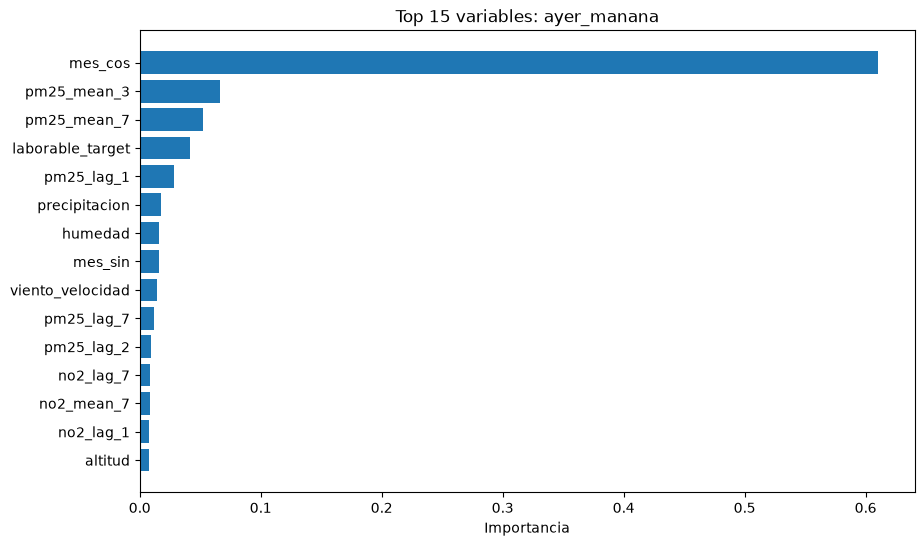


ayer_pasado_manana


,feature,importance
33,mes_cos,0.618078
8,pm25_mean_7,0.054580
7,pm25_mean_3,0.049641
31,laborable_target,0.038357
26,precipitacion,0.020154
25,humedad,0.019907
4,pm25_lag_1,0.019798
32,mes_sin,0.018419
28,viento_velocidad,0.014332
6,pm25_lag_7,0.011932


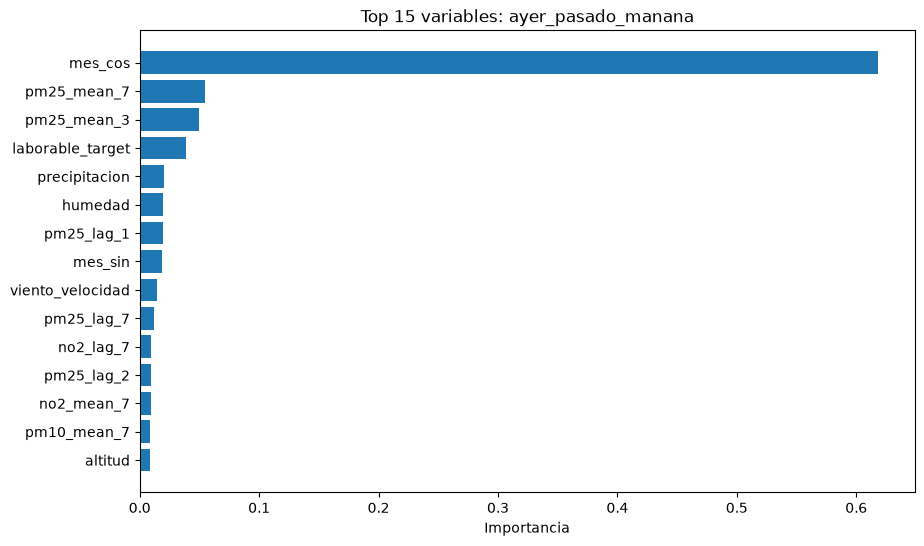


hoy_manana


,feature,importance
33,mes_cos,0.589043
7,pm25_mean_3,0.068419
8,pm25_mean_7,0.055521
31,laborable_target,0.042097
4,pm25_lag_1,0.031237
26,precipitacion,0.018162
25,humedad,0.017191
32,mes_sin,0.017070
28,viento_velocidad,0.014794
6,pm25_lag_7,0.012619


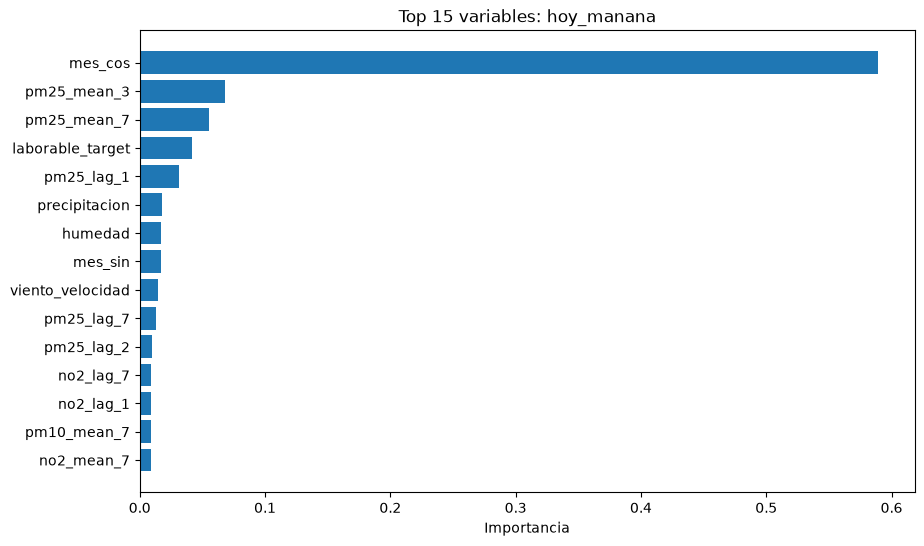

In [10]:
for name, model in models_base.items():
    features = predictions_base[name]["features"]

    importance = (
        pd.DataFrame({
            "feature": features,
            "importance": model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
    )

    print(f"\n{name}")
    display(importance.head(20))

    top = importance.head(15).sort_values("importance")

    plt.figure(figsize=(10, 6))
    plt.barh(top["feature"], top["importance"])
    plt.title(f"Top 15 variables: {name}")
    plt.xlabel("Importancia")
    plt.show()


## 8. XGBoost con validación temporal para cada escenario

In [11]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

tuned_models = {}
tuned_predictions = {}

for name, parts in splits.items():

    train = parts["train"]
    features = get_feature_columns(parts["all"])

    # CV temporal: cada fold respeta el orden de las fechas.
    dates = np.sort(train["fecha_referencia"].unique())
    n_splits = 3
    folds = []

    for i in range(1, n_splits + 1):
        cut1 = int(len(dates) * i / (n_splits + 1))
        cut2 = int(len(dates) * (i + 1) / (n_splits + 1))

        if cut1 >= cut2:
            continue

        train_dates = dates[:cut1]
        val_dates = dates[cut1:cut2]

        tr_idx = train.index[train["fecha_referencia"].isin(train_dates)]
        va_idx = train.index[train["fecha_referencia"].isin(val_dates)]

        folds.append((tr_idx.to_numpy(), va_idx.to_numpy()))

    X_train = train[features]
    y_train = train[TARGET]

    xgb_base = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    grid = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=folds,
        n_jobs=-1,
        verbose=1,
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    tuned_models[name] = best_model

    val = parts["val"]
    test = parts["test"]

    pred_val = best_model.predict(val[features])
    pred_test = best_model.predict(test[features])

    tuned_predictions[name] = {
        "val": pred_val,
        "test": pred_test,
        "features": features,
    }

    results.extend([
        {
            "escenario": name,
            "modelo": "XGBoost tuned",
            "split": "validation",
            "MAE": mean_absolute_error(val[TARGET], pred_val),
            "RMSE": np.sqrt(mean_squared_error(val[TARGET], pred_val)),
            "R2": r2_score(val[TARGET], pred_val),
        },
        {
            "escenario": name,
            "modelo": "XGBoost tuned",
            "split": "test",
            "MAE": mean_absolute_error(test[TARGET], pred_test),
            "RMSE": np.sqrt(mean_squared_error(test[TARGET], pred_test)),
            "R2": r2_score(test[TARGET], pred_test),
        },
    ])

    print(f"\n{name}")
    print("Mejores parámetros:", grid.best_params_)
    print("Mejor RMSE CV:", -grid.best_score_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits

ayer_manana
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Mejor RMSE CV: 13.546284430368084
Fitting 3 folds for each of 24 candidates, totalling 72 fits

ayer_pasado_manana
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Mejor RMSE CV: 14.102136620043794
Fitting 3 folds for each of 24 candidates, totalling 72 fits

hoy_manana
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Mejor RMSE CV: 13.560939234556578


## 9. Comparación final de los tres escenarios

In [12]:
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset=["escenario", "modelo", "split"],
        keep="last"
    )
    .sort_values(["split", "RMSE"])
    .reset_index(drop=True)
)

display(results_df)

print("\nMejor modelo por escenario en validation:")
display(
    results_df[
        results_df["split"] == "validation"
    ]
    .sort_values("RMSE")
    .groupby("escenario", as_index=False)
    .first()
)

print("\nMejor modelo por escenario en test:")
display(
    results_df[
        results_df["split"] == "test"
    ]
    .sort_values("RMSE")
    .groupby("escenario", as_index=False)
    .first()
)


,escenario,modelo,split,MAE,RMSE,R2
0,hoy_manana,XGBoost tuned,test,11.851996,14.507146,0.700144
1,ayer_manana,XGBoost tuned,test,11.847819,14.507408,0.698032
2,ayer_manana,XGBoost base,test,12.216379,15.014757,0.676542
3,hoy_manana,XGBoost base,test,12.205251,15.024417,0.678380
4,ayer_pasado_manana,XGBoost tuned,test,12.525109,15.274589,0.664718
5,ayer_pasado_manana,XGBoost base,test,12.979669,15.933952,0.635147
6,hoy_manana,XGBoost tuned,validation,10.987124,13.934584,0.647671
7,ayer_manana,XGBoost tuned,validation,10.998986,13.945713,0.649606
8,hoy_manana,XGBoost base,validation,11.382791,14.340947,0.626822
9,ayer_manana,XGBoost base,validation,11.411278,14.353265,0.628826



Mejor modelo por escenario en validation:


,escenario,modelo,split,MAE,RMSE,R2
0,ayer_manana,XGBoost tuned,validation,10.998986,13.945713,0.649606
1,ayer_pasado_manana,XGBoost tuned,validation,11.744784,14.833531,0.602925
2,hoy_manana,XGBoost tuned,validation,10.987124,13.934584,0.647671



Mejor modelo por escenario en test:


,escenario,modelo,split,MAE,RMSE,R2
0,ayer_manana,XGBoost tuned,test,11.847819,14.507408,0.698032
1,ayer_pasado_manana,XGBoost tuned,test,12.525109,15.274589,0.664718
2,hoy_manana,XGBoost tuned,test,11.851996,14.507146,0.700144


## 10. Comparación visual del error

modelo,XGBoost base,XGBoost tuned
escenario,,
ayer_manana,15.014757,14.507408
ayer_pasado_manana,15.933952,15.274589
hoy_manana,15.024417,14.507146


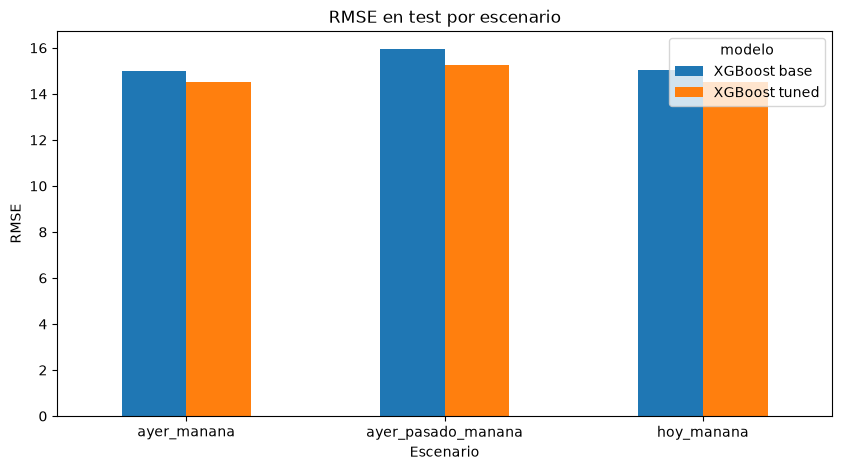

In [13]:
comparison = (
    results_df[
        (results_df["modelo"].isin(["XGBoost base", "XGBoost tuned"])) &
        (results_df["split"] == "test")
    ]
    .pivot_table(
        index="escenario",
        columns="modelo",
        values="RMSE",
    )
)

display(comparison)

comparison.plot(
    kind="bar",
    figsize=(10, 5),
    title="RMSE en test por escenario",
)
plt.ylabel("RMSE")
plt.xlabel("Escenario")
plt.xticks(rotation=0)
plt.show()


## 11. Predicción por estación

In [14]:
for name, parts in splits.items():
    test = parts["test"].copy()
    pred = tuned_predictions[name]["test"]

    test["pred"] = pred
    test["error_abs"] = (
        test[TARGET] - test["pred"]
    ).abs()

    station_metrics = (
        test.groupby("estacion")
        .apply(
            lambda g: pd.Series({
                "MAE": mean_absolute_error(
                    g[TARGET], g["pred"]
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        g[TARGET], g["pred"]
                    )
                ),
                "n": len(g),
            }),
            include_groups=False,
        )
        .sort_values("RMSE")
    )

    print(f"\n{name}")
    display(station_metrics)



ayer_manana


,MAE,RMSE,n
estacion,,,
8,10.443268,12.740035,364.0
35,11.145476,13.603527,364.0
17,11.523377,14.010167,364.0
18,11.657200,14.031796,364.0
16,11.500153,14.158379,364.0
60,11.523684,14.169817,364.0
27,11.562575,14.266671,364.0
39,11.938491,14.526286,364.0
54,12.137089,14.879933,364.0



ayer_pasado_manana


,MAE,RMSE,n
estacion,,,
8,10.918400,13.308310,363.0
35,11.841320,14.312274,363.0
18,12.565730,14.850618,363.0
60,12.199127,14.906438,363.0
27,12.202495,14.980161,363.0
16,12.215920,15.025158,363.0
17,12.478222,15.112548,363.0
39,12.458142,15.280788,363.0
59,12.557942,15.458469,363.0



hoy_manana


,MAE,RMSE,n
estacion,,,
8,10.451472,12.787393,365.0
35,11.160773,13.612947,365.0
18,11.633705,14.005929,365.0
17,11.600989,14.090011,365.0
16,11.513993,14.140451,365.0
60,11.481170,14.148832,365.0
27,11.609550,14.322660,365.0
39,11.956440,14.557403,365.0
54,12.130258,14.852973,365.0


In [ ]:
# Exportacion para el predictor ensemble
from pathlib import Path
import joblib

model = best_model
features_to_export = list(model.feature_names_in_)
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'models' / 'xgboost').exists())
output_dir = project_root / 'src' / 'models' / 'xgboost' / 'O3'
joblib.dump(model, output_dir / 'modelo_o3_final.joblib')
joblib.dump(features_to_export, output_dir / 'features_o3_final.joblib')
print(f'Modelo y features exportados en: {output_dir}')